In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
load_dotenv()

True

In [3]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_urdu: str

In [4]:
parent_llm =  ChatOpenAI()
subgraph_llm = ChatOpenAI()

In [6]:
def translate_text(state: ParentState):
    prompt = f"""Translate the following text to Urdu: Keep it natural and clear. Do not add extra Content
Text:
{state['answer_eng']}

""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content
    state['answer_urdu'] = translated_text
    return state

In [7]:
sub_graph_builder = StateGraph(ParentState)

sub_graph_builder.add_node('translate_text',translate_text)
sub_graph_builder.add_edge(START, 'translate_text')
sub_graph_builder.add_edge('translate_text', END)

subgraph = sub_graph_builder.compile()

In [8]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(f"You are the helpful assistant. Answer clearly. \n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [9]:
parent_graph_builder = StateGraph(ParentState)
parent_graph_builder.add_node('generate_answer', generate_answer)
parent_graph_builder.add_node('translate_answer', subgraph)

parent_graph_builder.add_edge(START, 'generate_answer')
parent_graph_builder.add_edge('generate_answer', 'translate_answer')
parent_graph_builder.add_edge('translate_answer', END)

parent_graph = parent_graph_builder.compile()


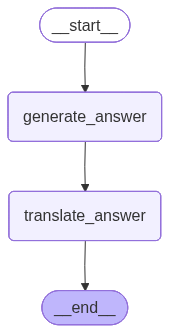

In [10]:
parent_graph

In [11]:
parent_graph.invoke({'question': 'What is quantum physics?'})

{'question': 'What is quantum physics?',
 'answer_eng': 'Quantum physics is the branch of physics that studies the physical nature of matter at the smallest scales of energy levels of atoms and subatomic particles. It incorporates principles such as wave-particle duality, quantization, and the uncertainty principle to explain the behavior of these systems.',
 'answer_urdu': 'مضمون کو قدرتی اور واضح رکھیں۔ اضافی مواد شامل نہ کریں۔ كوانٹم فزکس وہ فزکس کی شاخ ہے جو اشیاء کی طبیعیت کا مطالعہ کرتی ہے ان کے چھوٹے سطحوں پر اینرجی سطحوں اور ذرات کی. یہ اصول شامل ہوتا ہے جیسے زمانے ذرے کے دوئیت، مقداربندی، اور ان یظرس کی روانی کی وضاحت کرنے کے لئے۔'}